In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from datetime import datetime

In [2]:
POSITIONS = [
    'sit',
    'stand',
    'standtandem',
    'standsingle',
    'sts'
]

VARIATIONS = [
    '',
    'eyesclosed',
    'foam',
    'foameyesclosed'
]

In [ ]:
position = 0
variation = 1
TEST = f'{POSITIONS[position]}{VARIATIONS[variation]}'

opti_filename = f"/Users/edwardzhou/Desktop/FRL/BalanceProject/data/4-10/optitrack/410{TEST}_opti.csv"

with open(opti_filename, 'r') as f:
    metadata = next(f)
    metadata_list = metadata.split(',')
    metadata_dict = {metadata_list[i]: metadata_list[i+1] for i in range(0, len(metadata_list), 2)}

    df_opti = pd.read_csv(f, skiprows=4, header=[0, 1])
    

start_time = datetime.strptime(metadata_dict['Capture Start Time'], "%Y-%m-%d %I.%M.%S.%f %p")

df_opti = df_opti.iloc[:, :8]
df_opti.columns = ["_".join([i.lower() for i in col if "Unnamed" not in i]) for col in df_opti.columns.values]
df_opti['timestampEpoch'] = df_opti['time (seconds)'] + start_time.timestamp()
df_opti['timestampEpoch'] *= 1000
# df_opti

In [ ]:
app_filename = f"/Users/edwardzhou/Desktop/FRL/BalanceProject/data/4-10/airpods/410{TEST}.csv"
df_app = pd.read_csv(app_filename)
df_app = df_app.loc[df_app["source"] == "airpods"]
# df_app

In [ ]:
time_opti = df_opti["timestampEpoch"].values
time_app = df_app["timestampEpoch"].values

# Mask to get overlapping time only
time_start = max(time_opti[0], time_app[0])
time_end = min(time_opti[-1], time_app[-1])
mask_opti = (time_opti >= time_start) & (time_opti <= time_end)
mask_app = (time_app >= time_start) & (time_app <= time_end)

time_opti = time_opti[mask_opti]
df_opti = df_opti[mask_opti]
time_app = time_app[mask_app]
df_app = df_app[mask_app]

# frame transform
# T = np.array([[0, 0, -1], [-1, 0, 0], [0, 1, 0]])
# R_opti = rot_opti.as_matrix()
# R_transformed = T @ R_opti @ T.T

# rot_opti = R.from_matrix(R_transformed)

# euler_opti = unwrap_euler(rot_opti.as_euler("xyz", degrees=True))
# euler_app = unwrap_euler(rot_app.as_euler("xyz", degrees=True))

pitch_a = df_app['angle_pitch'] * 180 / np.pi
roll_a = df_app['angle_roll'] * 180 / np.pi
yaw_a = df_app['angle_yaw'] * 180 / np.pi
pitch_o = df_opti['rotation_x']
roll_o = df_opti['rotation_y']
yaw_o = df_opti['rotation_z']

fig, axes = plt.subplots(3, 1, figsize=(18, 30), sharex=True)

axes[0].plot(time_opti, pitch_o, label="Pitch (optitrack)")
axes[0].plot(time_app, pitch_a, linestyle="--", label="Pitch (airpods)")
axes[0].set_ylabel("Pitch")
axes[0].set_ylim(bottom=-90, top=90)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time_opti, roll_o, label="Roll (optitrack)")
axes[1].plot(time_app, roll_a, linestyle="--", label="Roll (airpods)")
axes[1].set_ylabel("Roll")
axes[1].set_ylim(bottom=-90, top=90)
axes[1].legend()
axes[1].grid(True)

axes[2].plot(time_opti, yaw_o, label="Yaw (optitrack)")
axes[2].plot(time_app, yaw_a, linestyle="--", label="Yaw (airpods)")
axes[2].set_ylabel("Yaw")
axes[2].set_xlabel("Timestamp")
axes[2].set_ylim(bottom=-90, top=90)
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Rotation vs Time")
plt.show()


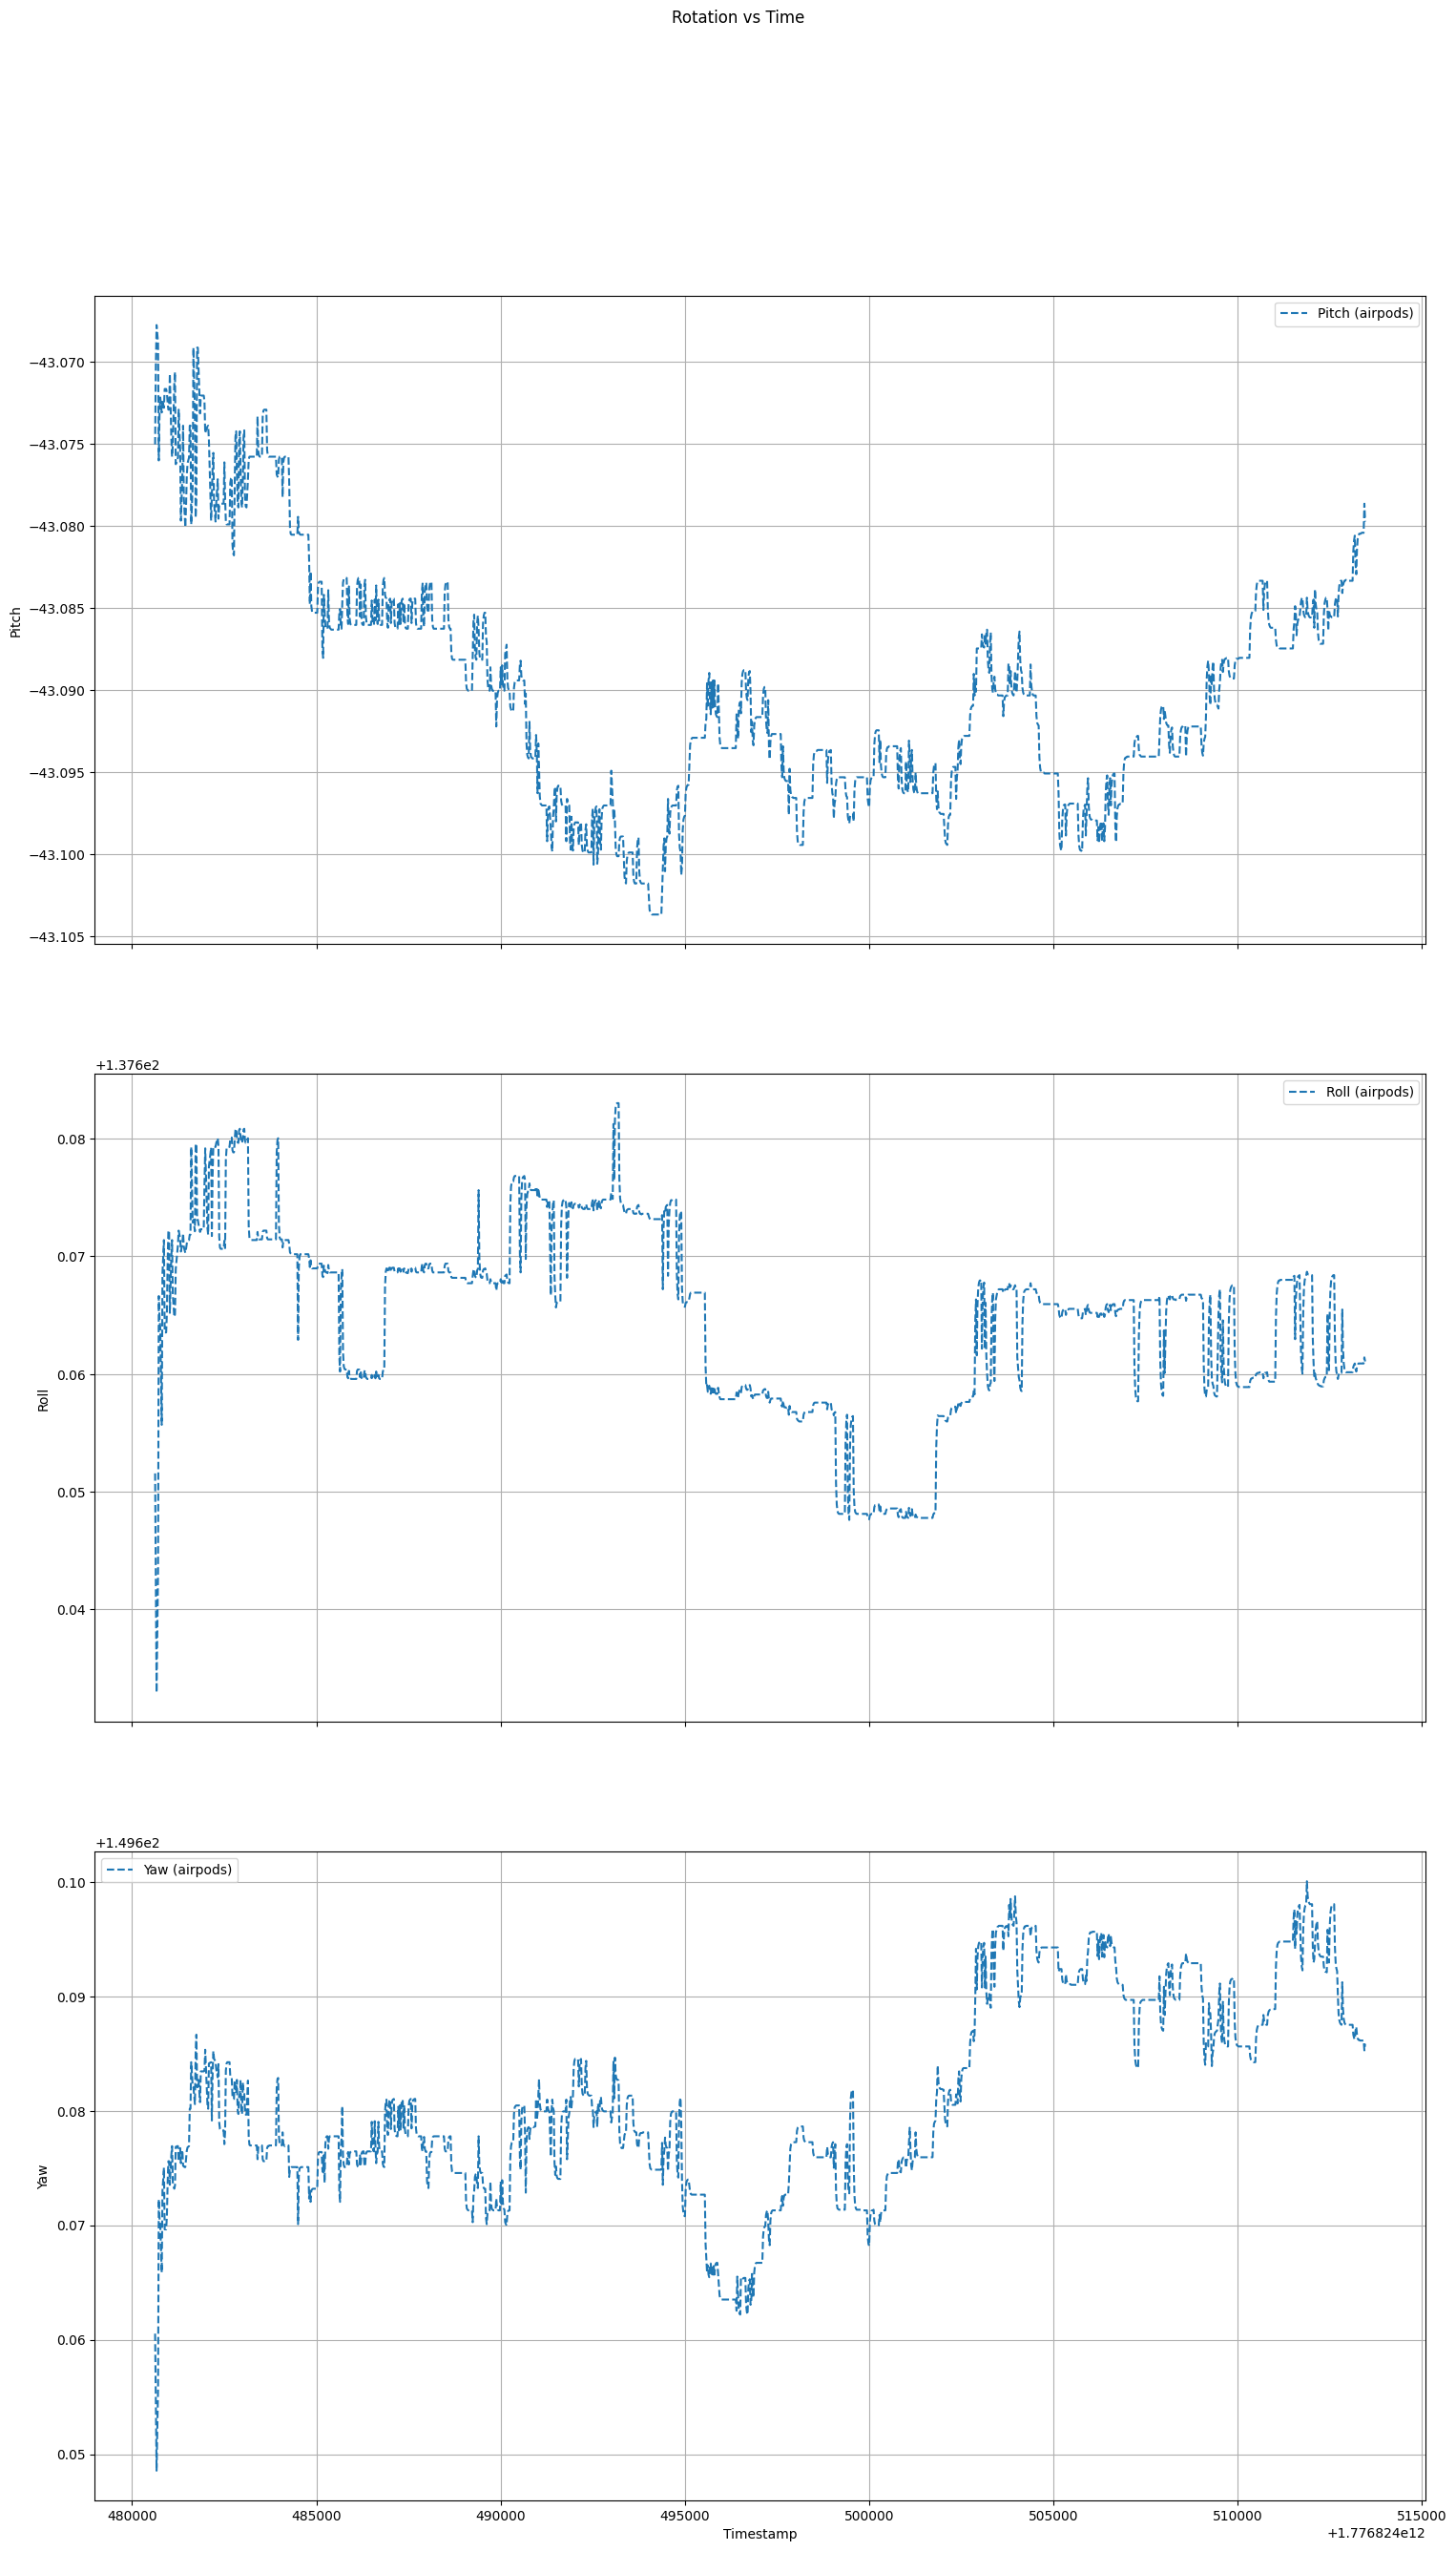

In [26]:
app_filename = "/Users/edwardzhou/Downloads/idle1.csv"

df_app = pd.read_csv(app_filename)
df_app = df_app.loc[df_app["source"] == "airpods"]

time_app = df_app["timestampEpoch"].values[10:-10]

pitch_a = df_app['angle_pitch'].values[10:-10] * 180 / np.pi
roll_a = df_app['angle_roll'].values[10:-10] * 180 / np.pi
yaw_a = df_app['angle_yaw'].values[10:-10] * 180 / np.pi

fig, axes = plt.subplots(3, 1, figsize=(18, 30), sharex=True)

axes[0].plot(time_app, pitch_a, linestyle="--", label="Pitch (airpods)")
axes[0].set_ylabel("Pitch")
# axes[0].set_ylim(bottom=-90, top=90)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time_app, roll_a, linestyle="--", label="Roll (airpods)")
axes[1].set_ylabel("Roll")
# axes[1].set_ylim(bottom=-90, top=90)
axes[1].legend()
axes[1].grid(True)

axes[2].plot(time_app, yaw_a, linestyle="--", label="Yaw (airpods)")
axes[2].set_ylabel("Yaw")
axes[2].set_xlabel("Timestamp")
# axes[2].set_ylim(bottom=-90, top=90)
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Rotation vs Time")
plt.show()

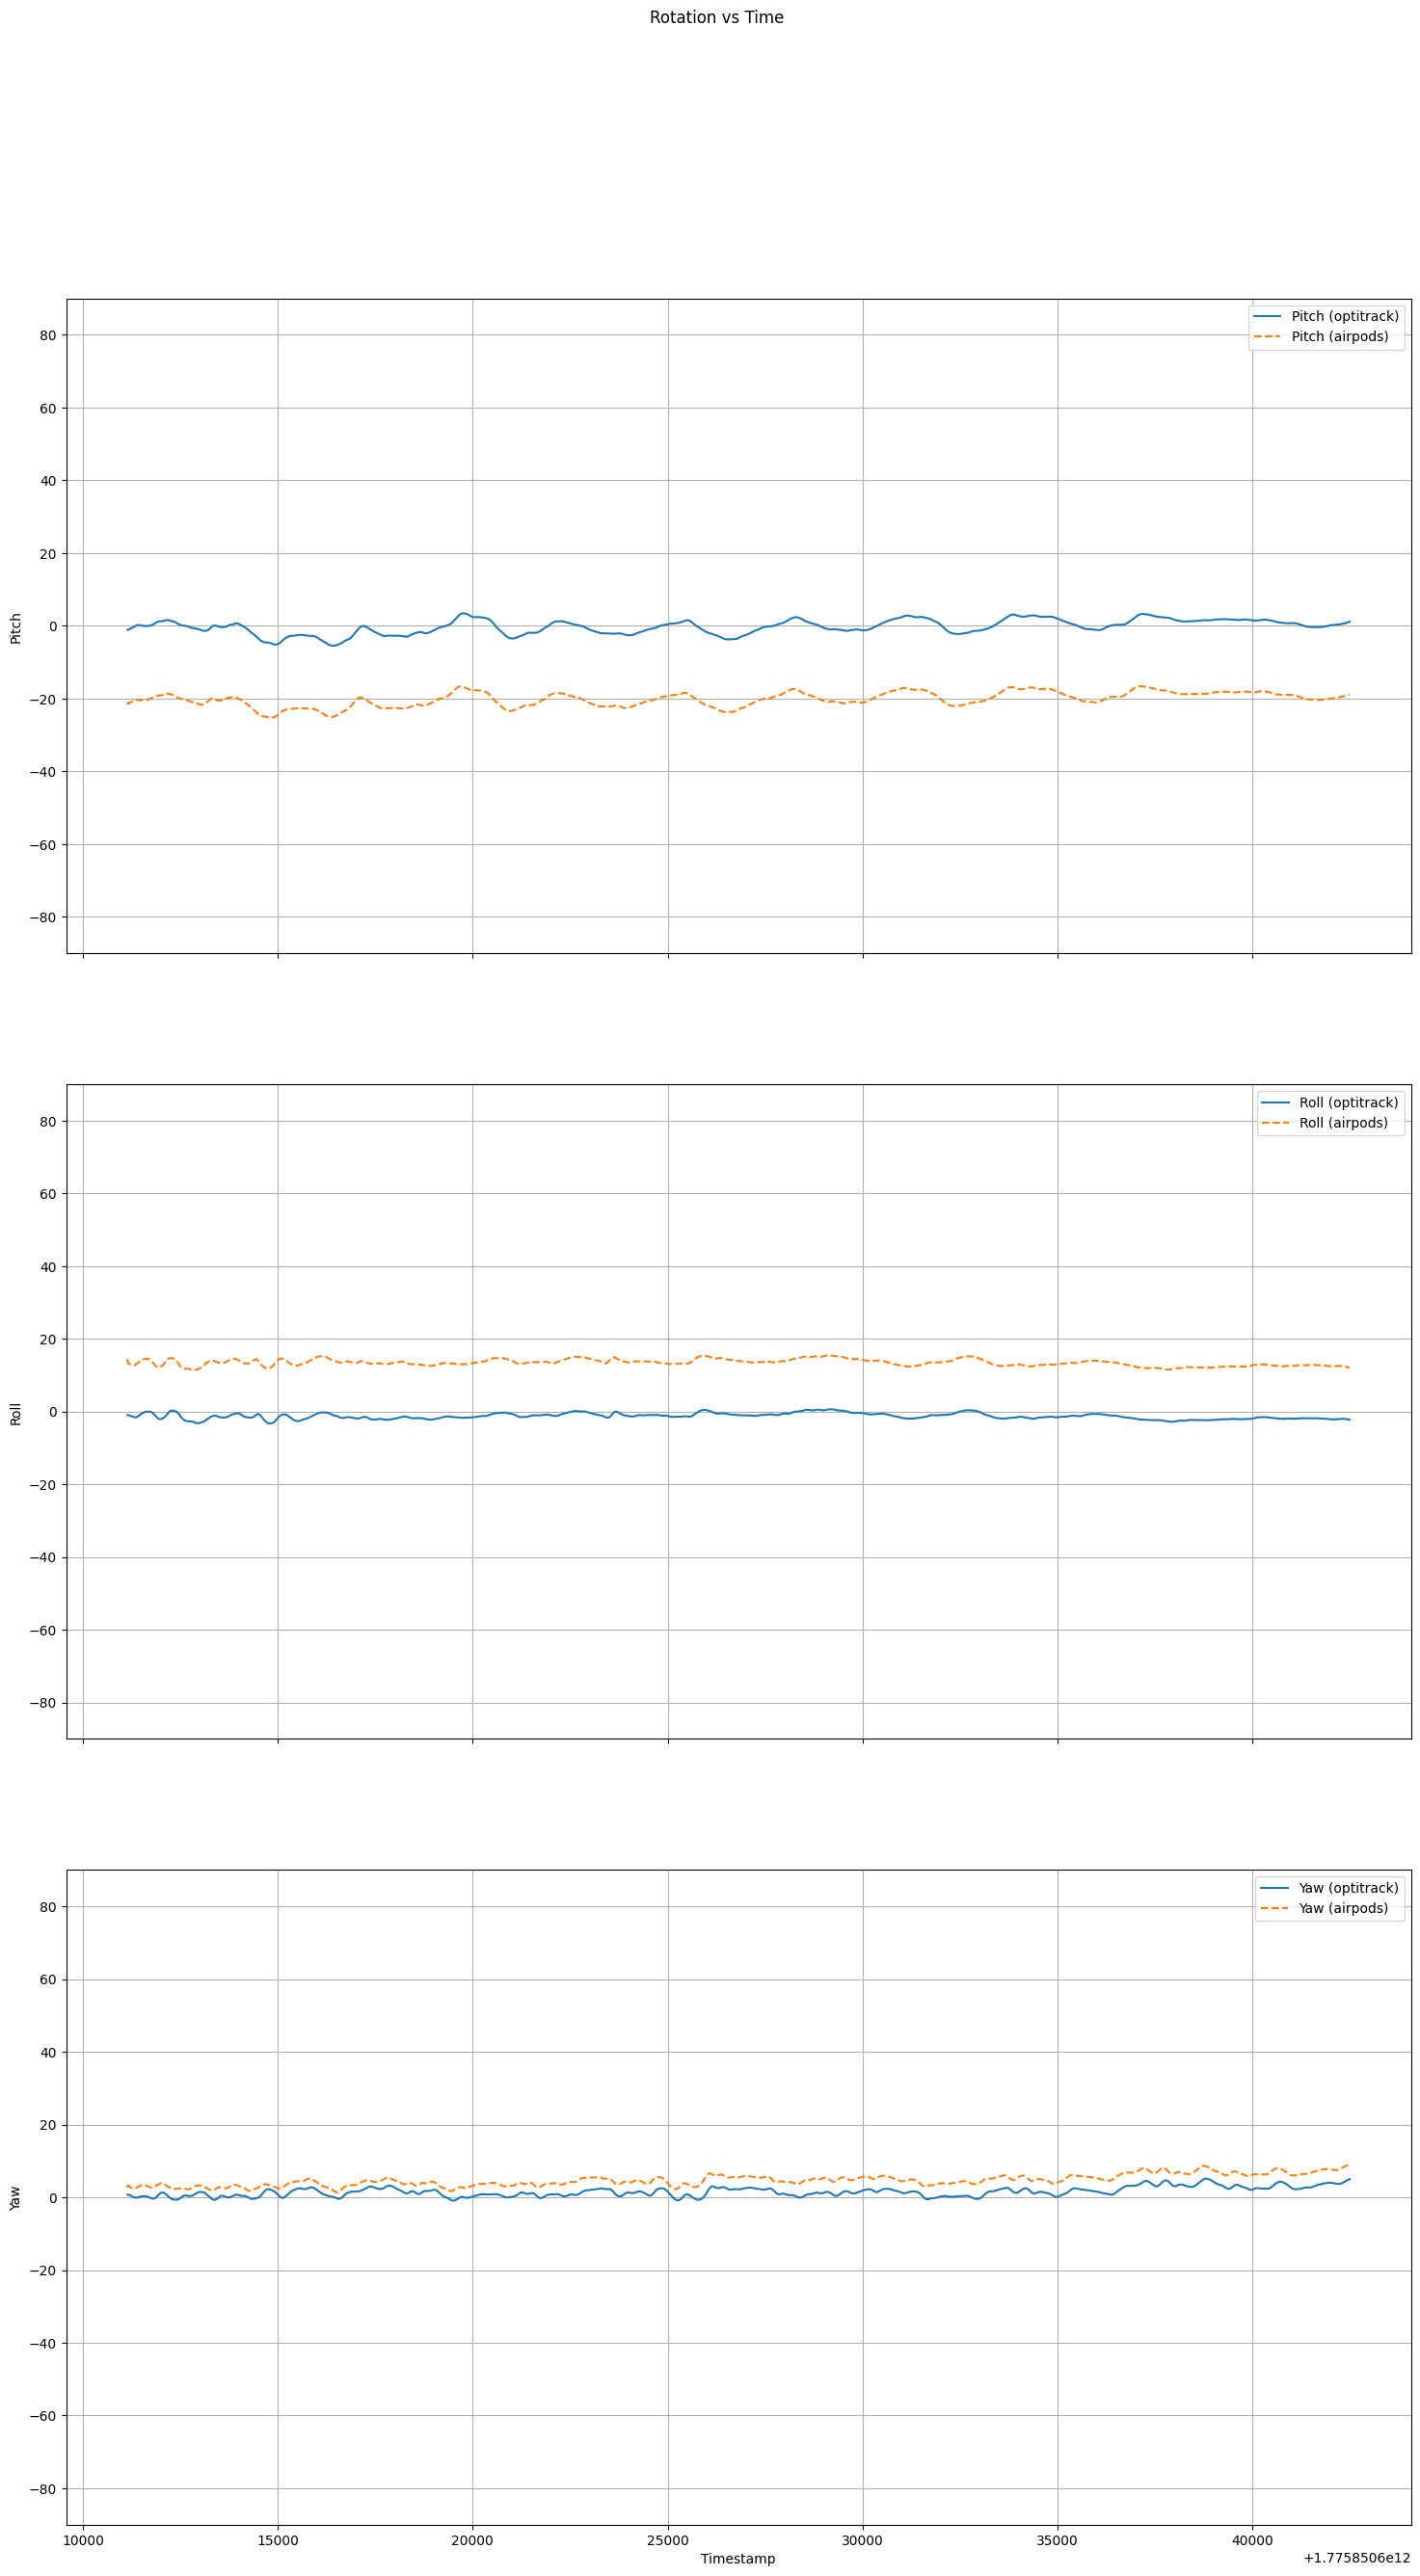

In [21]:
POSITIONS = [
    'sit',
    'stand',
    'standtandem',
    'standsingle',
    'sts'
]

VARIATIONS = [
    '',
    'eyesclosed',
    'foam',
    'foameyesclosed'
]

position = 1
variation = 3
TEST = f'{POSITIONS[position]}{VARIATIONS[variation]}'

opti_filename = f"/Users/edwardzhou/Desktop/FRL/BalanceProject/data/4-10/optitrack/410{TEST}_opti.csv"
app_filename = f"/Users/edwardzhou/Desktop/FRL/BalanceProject/data/4-10/airpods/410{TEST}.csv"

with open(opti_filename, 'r') as f:
    metadata = next(f)
    metadata_list = metadata.split(',')
    metadata_dict = {metadata_list[i]: metadata_list[i+1] for i in range(0, len(metadata_list), 2)}

    df_opti = pd.read_csv(f, skiprows=4, header=[0, 1])
    

start_time = datetime.strptime(metadata_dict['Capture Start Time'], "%Y-%m-%d %I.%M.%S.%f %p")

df_opti = df_opti.iloc[:, :8]
df_opti.columns = ["_".join([i.lower() for i in col if "Unnamed" not in i]) for col in df_opti.columns.values]
df_opti['timestampEpoch'] = df_opti['time (seconds)'] + start_time.timestamp()
df_opti['timestampEpoch'] *= 1000

df_app = pd.read_csv(app_filename)
df_app = df_app.loc[df_app["source"] == "airpods"]

time_opti = df_opti["timestampEpoch"].values - 800
time_app = df_app["timestampEpoch"].values

# Mask to get overlapping time only
time_start = max(time_opti[0], time_app[0])
time_end = min(time_opti[-1], time_app[-1])
mask_opti = (time_opti >= time_start) & (time_opti <= time_end)
mask_app = (time_app >= time_start) & (time_app <= time_end)

time_opti = time_opti[mask_opti]
df_opti = df_opti[mask_opti]
time_app = time_app[mask_app]
df_app = df_app[mask_app]

pitch_a = df_app['angle_pitch'] * 180 / np.pi
roll_a = df_app['angle_roll'] * 180 / np.pi
yaw_a = df_app['angle_yaw'] * 180 / np.pi
pitch_o = df_opti['rotation_x']
roll_o = df_opti['rotation_y']
yaw_o = df_opti['rotation_z']

fig, axes = plt.subplots(3, 1, figsize=(18, 30), sharex=True)

axes[0].plot(time_opti, pitch_o, label="Pitch (optitrack)")
axes[0].plot(time_app, pitch_a, linestyle="--", label="Pitch (airpods)")
axes[0].set_ylabel("Pitch")
axes[0].set_ylim(bottom=-90, top=90)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time_opti, roll_o, label="Roll (optitrack)")
axes[1].plot(time_app, roll_a, linestyle="--", label="Roll (airpods)")
axes[1].set_ylabel("Roll")
axes[1].set_ylim(bottom=-90, top=90)
axes[1].legend()
axes[1].grid(True)

axes[2].plot(time_opti, yaw_o, label="Yaw (optitrack)")
axes[2].plot(time_app, yaw_a, linestyle="--", label="Yaw (airpods)")
axes[2].set_ylabel("Yaw")
axes[2].set_xlabel("Timestamp")
axes[2].set_ylim(bottom=-90, top=90)
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Rotation vs Time")
plt.show()
